In [1]:
# Настраиваем ноутбук
import pytest
import ipytest
ipytest.autoconfig()

# Зачем нужны тесты?

Каждое изменение в коде либо подвержено проверками, либо делается на в надежде, что всё правильно.

Тесты превращают веру в уверенность.

In [2]:
def calculate_discount(price, discount_percent):
    return price * (1 - discount_percent / 100)

Сломает ли следующее изменение ваш код?

In [3]:
def calculate_discount(price, discount_percent):
    return round(price * (1 - discount_percent / 100))

## Почему в Python эти тесты особенно важны

python - язык с динамической типизацией. Некоторые проблемы вы увидите не сразу.

In [4]:
import json

def print_products(product_json: str) -> None:
    product = json.loads(product_json)['product']
    print("Print: ", product)

print_products('{"product":"apple"}')

Print:  apple


In [5]:
print_products('{"product":{"name":"apple", "cost":3}}')

Print:  {'name': 'apple', 'cost': 3}


## Пирамида тестирования (подробнее [тут](https://habr.com/ru/articles/672484/))


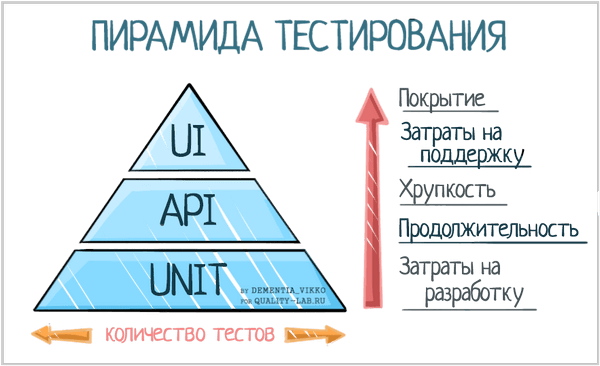

## Виды тестов

По уровню
* unit-тесты
* интеграционные тесты
* системные тесты
* приёмочные тесты

По цели
* функциональные
* нефункциональные

## Главный инженерный принцип в тестировании

Тест должен проверять поведение системы, а не детали её внутренней реализации.

# Тестирование и python

## Библиотеки

Для автоматизированного тестирования написано много фреймворков на разных языках. Короткий список для python:

* [unittest](https://docs.python.org/3/library/unittest.html)
* [nose2](https://docs.nose2.io/en/latest/)
* [pytest](https://docs.pytest.org/en/latest/)

В рамках лекции мы остановимся на `pytest`.

#### Как pytest находит тесты

1. Рекурсивно находит все python-файлы в текущей директории
2. Оставляет только файлы вида `test_*.py` и `*_test.py`
3. В этих файлах:
    1. Находит все функции с префиксом `test`
    2. Находит все методы с префиксом `test` внутри классов с префиксом `Test`. У классов не должно быть метода `__init__`
  
Поведение можно модифицировать. [Подробнее в документации](https://docs.pytest.org/en/stable/goodpractices.html#test-discovery).

In [6]:
%%ipytest

def test_good_math():
    assert 2 + 2 == 4


def test_bad_math():
    assert 2 + 2 == 5


.F                                                                                           [100%]
============================================= FAILURES =============================================
__________________________________________ test_bad_math ___________________________________________

    def test_bad_math():
>       assert 2 + 2 == 5
E       assert (2 + 2) == 5

/var/folders/pt/23tj0wb152j7xlcvqk_tty580000gn/T/ipykernel_13550/2043010901.py:6: AssertionError
===================================== short test summary info ======================================
FAILED t_a96a7d60afed40319db857d9a5f28eb7.py::test_bad_math - assert (2 + 2) == 5
1 failed, 1 passed in 0.06s


`pytest` выводит отчет, в котором можно посмотреть сколько у нас всего тестов, какие из них упали и по какой причине. 


## TDD и каты

TDD — test-driven developement или разработка через тестирование.

**Три правила TDD**:

 - Продакшн-код можно писать только для починки падающего теста.
 - В тесте нужно писать ровно столько кода, сколько необходимо, чтобы он упал. Ошибки компиляции считаются падениями теста.
 - В продакшн можно написать ровно столько кода, сколько требуется для починки одного падающего теста.


Получается следйющий пайплайн: пишем падающий тест, пишем код, чтобы тест не падал, рефакторим код так, чтобы тесты не падали. Повторяем до сходимости.

Есть пара книжек по теме:

1. [Test Driven Development: By Example 1st Edition](https://www.amazon.com/Test-Driven-Development-Kent-Beck/dp/0321146530)
2. [On Growing Object Oriented Software, Guided by Tests](https://www.amazon.com/Growing-Object-Oriented-Software-Guided-Tests/dp/0321503627)

К прочтению рекомендуется вторая, т.к. она более приближена к разработческим реалиям.

### Каты

Каты — упражнения по программированию, помогающие отточить навыки путем многократного повторнения. Концепция взята из японских боевых искусств. Подробнее про них можно почитать в книжке [The Pragmatic Programmer](https://pragprog.com/titles/tpp20/the-pragmatic-programmer-20th-anniversary-edition/)



**Ката Greeter**

Эту кату надо выполнять строго по пунктам, не заглядывая вперёд.

- Создайте класс `Greeter`, у которого есть метод `greet` принимающий на вход имя и возвращающий "Hello <имя>".

Напишем минимальный тест:

In [7]:
%%ipytest

def test_greeter():
    Greeter()

F                                                                                            [100%]
============================================= FAILURES =============================================
___________________________________________ test_greeter ___________________________________________

    def test_greeter():
>       Greeter()
        ^^^^^^^
E       NameError: name 'Greeter' is not defined

/var/folders/pt/23tj0wb152j7xlcvqk_tty580000gn/T/ipykernel_13550/896734415.py:2: NameError
===================================== short test summary info ======================================
FAILED t_a96a7d60afed40319db857d9a5f28eb7.py::test_greeter - NameError: name 'Greeter' is not defined
1 failed in 0.01s


Теперь сделаем так, чтобы тест проходил:

In [8]:
class Greeter:
    pass

In [9]:
%%ipytest

def test_greeter():
    Greeter()

.                                                                                            [100%]
1 passed in 0.01s


Еще одна итерация TDD:

In [10]:
%%ipytest

def test_greeter():
    Greeter().greet("Mike")

F                                                                                            [100%]
============================================= FAILURES =============================================
___________________________________________ test_greeter ___________________________________________

    def test_greeter():
>       Greeter().greet("Mike")
        ^^^^^^^^^^^^^^^
E       AttributeError: 'Greeter' object has no attribute 'greet'

/var/folders/pt/23tj0wb152j7xlcvqk_tty580000gn/T/ipykernel_13550/2409606644.py:2: AttributeError
===================================== short test summary info ======================================
FAILED t_a96a7d60afed40319db857d9a5f28eb7.py::test_greeter - AttributeError: 'Greeter' object has no attribute 'greet'
1 failed in 0.01s


In [11]:
class Greeter:
    def greet(self, name):
        return ""

In [12]:
%%ipytest

def test_greeter():
    Greeter().greet("Mike")

.                                                                                            [100%]
1 passed in 0.01s


Теперь наконец-то напишем нормальный тест, воспользовавшись основной фишкой `Pytest`: `assert`. `Pytest` находит все вызовы `assert` в коде тестов, а затем переписывает этот код так, чтобы в случае падения пользователь мог получить удобный дифф и трейсбек.

[Демки разных ассертов](https://docs.pytest.org/en/stable/example/reportingdemo.html#tbreportdemo).

In [13]:
%%ipytest

def test_greeter():
    assert Greeter().greet("Mike") == "Hello Mike"

F                                                                                            [100%]
============================================= FAILURES =============================================
___________________________________________ test_greeter ___________________________________________

    def test_greeter():
>       assert Greeter().greet("Mike") == "Hello Mike"
E       AssertionError: assert '' == 'Hello Mike'
E         
E         - Hello Mike

/var/folders/pt/23tj0wb152j7xlcvqk_tty580000gn/T/ipykernel_13550/1592567342.py:2: AssertionError
===================================== short test summary info ======================================
FAILED t_a96a7d60afed40319db857d9a5f28eb7.py::test_greeter - AssertionError: assert '' == 'Hello Mike'
1 failed in 0.01s


Починим тест:

In [14]:
class Greeter:
    def greet(self, name):
        return "Hello Mike"

In [15]:
%%ipytest

def test_greeter():
    assert Greeter().greet("Mike") == "Hello Mike"

.                                                                                            [100%]
1 passed in 0.01s


## 2. Параметризация

Наша реализация представляет собой немного не то, что мы хотели. Стоит добавить больше разных тестов.
Чтобы не копировать один и тот же тест, можно воспользоваться параметризацией:

In [16]:
%%ipytest
test_cases = [("Mike", "Hello Mike"), ("John", "Hello John"), ("Greg", "Hello Greg")]

@pytest.mark.parametrize("name, greeting", test_cases)
def test_greeter(name, greeting):
    assert Greeter().greet(name) == greeting

.FF                                                                                          [100%]
============================================= FAILURES =============================================
__________________________________ test_greeter[John-Hello John] ___________________________________

name = 'John', greeting = 'Hello John'

    @pytest.mark.parametrize("name, greeting", test_cases)
    def test_greeter(name, greeting):
>       assert Greeter().greet(name) == greeting
E       AssertionError: assert 'Hello Mike' == 'Hello John'
E         
E         - Hello John
E         + Hello Mike

/var/folders/pt/23tj0wb152j7xlcvqk_tty580000gn/T/ipykernel_13550/2110350598.py:5: AssertionError
__________________________________ test_greeter[Greg-Hello Greg] ___________________________________

name = 'Greg', greeting = 'Hello Greg'

    @pytest.mark.parametrize("name, greeting", test_cases)
    def test_greeter(name, greeting):
>       assert Greeter().greet(name) == greeting
E       

Видим отчеты пайтеста во всей красе. Починим тесты:

In [17]:
class Greeter:
    def greet(self, name):
        return "Hello " + name

In [18]:
%%ipytest
test_cases = [("Mike", "Hello Mike"), ("John", "Hello John"), ("Greg", "Hello Greg")]

@pytest.mark.parametrize("name, greeting", test_cases)
def test_greeter(name, greeting):
    assert Greeter().greet(name) == greeting

...                                                                                          [100%]
3 passed in 0.01s


Перейдем к следующему пункту нашего задания:

- Метод `greet` должен убирать лишние пробелы в начале и в конце имени.

Опять же, напишем тест:

In [19]:
%%ipytest

def test_spaces():
    greeting = Greeter().greet(" Mike")
    assert not greeting.startswith(" ")

.                                                                                            [100%]
1 passed in 0.01s


Обратим внимание, что тест проходит и возникает соблазн продолжить работу. Однако если посмотреть на тест внимательно, можно увидеть в нем ошибку.


Чтобы не наступать на такие грабли, существует **правило** — только что написанный тест должен падать, при чём именно из-за того поведения, которое этот тест должен был покрыть.


Вы можете писать тесты на уже существующий код — в таком случае они могут не падать, т.к. код уже работает как надо. Тогда есть два варианта:
* Сделать в продовом коде баг чтобы тест упал
* Обратить проверяемое условие в тесте

Поправим наш тест:

In [20]:
%%ipytest

def test_spaces():
    greeted_name = Greeter().greet(" Mike").split(" ", 1)[1]
    assert not greeted_name.startswith(" ")

F                                                                                            [100%]
============================================= FAILURES =============================================
___________________________________________ test_spaces ____________________________________________

    def test_spaces():
        greeted_name = Greeter().greet(" Mike").split(" ", 1)[1]
>       assert not greeted_name.startswith(" ")
E       AssertionError: assert not True
E        +  where True = <built-in method startswith of str object at 0x10f2ac600>(' ')
E        +    where <built-in method startswith of str object at 0x10f2ac600> = ' Mike'.startswith

/var/folders/pt/23tj0wb152j7xlcvqk_tty580000gn/T/ipykernel_13550/3072710971.py:3: AssertionError
===================================== short test summary info ======================================
FAILED t_a96a7d60afed40319db857d9a5f28eb7.py::test_spaces - AssertionError: assert not True
1 failed in 0.01s


Починим тест

In [21]:
class Greeter:
    def greet(self, name):
        if name.startswith(" "):
            name = name[1:]
        return "Hello " + name

In [22]:
%%ipytest

def test_spaces():
    greeted_name = Greeter().greet(" Mike").split(" ", 1)[1]
    assert not greeted_name.startswith(" ")

.                                                                                            [100%]
1 passed in 0.01s


Перечитаем наше задание:
* Метод greet должен убирать лишние пробелы в начале и **в конце имени**

Видимо, нам нужно расширить тест:

In [23]:
%%ipytest

def test_spaces():
    greeted_name = Greeter().greet(" Mike ").split(" ", 1)[1]
    assert not greeted_name.startswith(" ") and not greeted_name.endswith(" ")

F                                                                                            [100%]
============================================= FAILURES =============================================
___________________________________________ test_spaces ____________________________________________

    def test_spaces():
        greeted_name = Greeter().greet(" Mike ").split(" ", 1)[1]
>       assert not greeted_name.startswith(" ") and not greeted_name.endswith(" ")
E       AssertionError: assert (not False and not True)
E        +  where False = <built-in method startswith of str object at 0x10f2ad020>(' ')
E        +    where <built-in method startswith of str object at 0x10f2ad020> = 'Mike '.startswith
E        +  and   True = <built-in method endswith of str object at 0x10f2ad020>(' ')
E        +    where <built-in method endswith of str object at 0x10f2ad020> = 'Mike '.endswith

/var/folders/pt/23tj0wb152j7xlcvqk_tty580000gn/T/ipykernel_13550/70835571.py:3: AssertionError
====

Починим тест:

In [24]:
class Greeter:
    def greet(self, name):
        if name.startswith(" "):
            name = name[1:]
        if name.endswith(" "):
            name = name[:-1]
        return "Hello " + name

In [25]:
%%ipytest

def test_spaces():
    greeted_name = Greeter().greet(" Mike ").split(" ", 1)[1]
    assert not greeted_name.startswith(" ") and not greeted_name.endswith(" ")

.                                                                                            [100%]
1 passed in 0.01s


Наш тест все еще недостаточно хорош. Хороший набор тестов должен покрывать разные граничные условия и заходить во все ветки исполнения кода. Параметризуем наш тест так, чтобы покрыть как можно ветвей исполнения кода:

In [26]:
%%ipytest

@pytest.mark.parametrize("name", ["Mike", " Mike", "Mike ", " Mike ", "  Mike", "  Mike  "])
def test_spaces(name):
    greeted_name = Greeter().greet(name).split(" ", 1)[1]
    assert not greeted_name.startswith(" ") and not greeted_name.endswith(" ")

....FF                                                                                       [100%]
============================================= FAILURES =============================================
_______________________________________ test_spaces[  Mike] ________________________________________

name = '  Mike'

    @pytest.mark.parametrize("name", ["Mike", " Mike", "Mike ", " Mike ", "  Mike", "  Mike  "])
    def test_spaces(name):
        greeted_name = Greeter().greet(name).split(" ", 1)[1]
>       assert not greeted_name.startswith(" ") and not greeted_name.endswith(" ")
E       AssertionError: assert (not True)
E        +  where True = <built-in method startswith of str object at 0x10f2ae0d0>(' ')
E        +    where <built-in method startswith of str object at 0x10f2ae0d0> = ' Mike'.startswith

/var/folders/pt/23tj0wb152j7xlcvqk_tty580000gn/T/ipykernel_13550/2234036477.py:4: AssertionError
______________________________________ test_spaces[  Mike  ] _______________________

Можно давать имена отдельным наборам параметров — тогда будет удобнее читать вывод пайтеста

In [27]:
%%ipytest

@pytest.mark.parametrize("name", ["Mike", " Mike", "Mike ", " Mike ", "  Mike", "  Mike  "],
                         ids=["no spaces", "left space", "right space", 
                              "two-side space", "double space", "two-sided double space"])
def test_spaces(name):
    greeted_name = Greeter().greet(name).split(" ", 1)[1]
    assert not greeted_name.startswith(" ") and not greeted_name.endswith(" ")

....FF                                                                                       [100%]
============================================= FAILURES =============================================
____________________________________ test_spaces[double space] _____________________________________

name = '  Mike'

    @pytest.mark.parametrize("name", ["Mike", " Mike", "Mike ", " Mike ", "  Mike", "  Mike  "],
                             ids=["no spaces", "left space", "right space",
                                  "two-side space", "double space", "two-sided double space"])
    def test_spaces(name):
        greeted_name = Greeter().greet(name).split(" ", 1)[1]
>       assert not greeted_name.startswith(" ") and not greeted_name.endswith(" ")
E       AssertionError: assert (not True)
E        +  where True = <built-in method startswith of str object at 0x10f2ae7c0>(' ')
E        +    where <built-in method startswith of str object at 0x10f2ae7c0> = ' Mike'.startswith

/var/folde

Починим тест:

In [28]:
class Greeter:
    def greet(self, name):
        while name.startswith(" "):
            name = name[1:]
        while name.endswith(" "):
            name = name[:-1]
        return "Hello " + name

In [29]:
%%ipytest

@pytest.mark.parametrize("name", ["Mike", " Mike", "Mike ", " Mike ", "  Mike", "  Mike  "],
                         ids=["no spaces", "left space", "right space", 
                              "two-side space", "double space", "two-sided double space"])
def test_spaces(name):
    greeted_name = Greeter().greet(name).split(" ", 1)[1]
    assert not greeted_name.startswith(" ") and not greeted_name.endswith(" ")

......                                                                                       [100%]
6 passed in 0.01s


Код кажется слишком многословным! Но при наличии тестов можно безбоязненно его порефакторить:

In [30]:
class Greeter:
    def greet(self, name):
        return "Hello " + name.strip()

In [31]:
%%ipytest


@pytest.mark.parametrize("name, greeting", [("Mike", "Hello Mike"), ("John", "Hello John"), ("Greg", "Hello Greg")])
def test_greeter(name, greeting):
    assert Greeter().greet(name) == greeting


@pytest.mark.parametrize("name", ["Mike", " Mike", "Mike ", " Mike ", "  Mike", "  Mike  "],
                         ids=["no spaces", "left space", "right space", 
                              "two-side space", "double space", "two-sided double space"])
def test_spaces(name):
    greeted_name = Greeter().greet(name).split(" ", 1)[1]
    assert not greeted_name.startswith(" ") and not greeted_name.endswith(" ")

.........                                                                                    [100%]
9 passed in 0.02s


## 3. Рефакторинг тестов и фикстуры

Сами тесты тоже надо рефакторить. У нас есть две проблемы.

Во-первых, имена тестов не очень информативны. Если упадет тест `test_greater`, будет не совсем понятно, что именно тестировалось и что надо чинить. В целом имена тестам надо давать как можно более подробные — тесты вызываются автоматически, автоматике длина имени безразлична, а вот человеку, читающему выхлоп пайтеста, лучше предоставить как можно больше информации.

[Статья на тему](https://enterprisecraftsmanship.com/posts/you-naming-tests-wrong).


Переименуем наши тесты:

In [32]:
%%ipytest


@pytest.mark.parametrize("name", ["Mike", "John", "Greg"])
def test_greet_returns_name_with_greeting(name):
    assert Greeter().greet(name) == "Hello " + name


@pytest.mark.parametrize("name", ["Mike", " Mike", "Mike ", " Mike ", "  Mike", "  Mike  "],
                         ids=["no spaces", "left space", "right space", 
                              "two-side space", "double space", "two-sided double space"])
def test_greet_removes_leading_and_trailing_spaces_from_name(name):
    greeted_name = Greeter().greet(name).split(" ", 1)[1]
    assert not greeted_name.startswith(" ") and not greeted_name.endswith(" ")

.........                                                                                    [100%]
9 passed in 0.02s


Вторая проблема — в обоих тестах мы создаем `greeter`. Это приводит к дублированию кода. Кроме того, на практике вместо `greeter` у нас может быть какой-нибудь тяжелый объект типа базы даных, который надо каждый раз инициализировать и чистить. Решить эти проблемы нам поможет механизм фикстур:

In [33]:
%%ipytest

@pytest.fixture(scope="module")
def greeter():
    yield Greeter()

@pytest.mark.parametrize("name", ["Mike", "John", "Greg"])
def test_greet_returns_name_with_greeting(greeter: Greeter, name: str):
    assert greeter.greet(name) == "Hello " + name


@pytest.mark.parametrize("name", ["Mike", " Mike", "Mike ", " Mike ", "  Mike", "  Mike  "],
                         ids=["no spaces", "left space", "right space", 
                              "two-side space", "double space", "two-sided double space"])
def test_greet_removes_leading_and_trailing_spaces_from_name(greeter, name):
    greeted_name = greeter.greet(name).split(" ", 1)[1]
    assert not greeted_name.startswith(" ") and not greeted_name.endswith(" ")

.........                                                                                    [100%]
9 passed in 0.01s


Фикстуры так же могут прибираться за создаваемым объектом в конце теста и иметь разный скоуп, например, создваться на каждый тест, модуль или тред, запускающий тесты. [Подробнее в документации](https://docs.pytest.org/en/6.2.x/fixture.html#fixture-scopes).

Для БД фикстура может выглядеть примерно так:

In [34]:
%%ipytest -s

class DBConnection:
    pass

class TestDB:
    def init_db(self):
        print("init db")
        
    def get_connection(self) -> DBConnection:
        return DBConnection()

    def shutdown(self):
        print("close db")


@pytest.fixture(scope="module")
def db_connection():
    db = TestDB()
    db.init_db()
    try:
        yield db.get_connection()
    finally:
        db.shutdown()
    
def test_db_1(db_connection: DBConnection):
    assert db_connection
    
def test_db_2(db_connection: DBConnection):
    assert db_connection

init db
..close db

2 passed in 0.01s


## 4. Тестирование исключений, сравнение флотов, манкипатчинг

Следующий пункт нашей каты:
- Метод `greet` должен возвращать ошибку если имя - пустая строка (или строка с пробелами)

Для тестирования исключений есть специальная функциональность:

In [35]:
%%ipytest

@pytest.fixture(scope="module")
def greeter():
    yield Greeter()

def test_greet_raises_value_error_on_empty_string(greeter):
    with pytest.raises(ValueError):
        greeter.greet("")

F                                                                                            [100%]
============================================= FAILURES =============================================
__________________________ test_greet_raises_value_error_on_empty_string ___________________________

greeter = <__main__.Greeter object at 0x10f39c230>

    def test_greet_raises_value_error_on_empty_string(greeter):
>       with pytest.raises(ValueError):
             ^^^^^^^^^^^^^^^^^^^^^^^^^
E       Failed: DID NOT RAISE <class 'ValueError'>

/var/folders/pt/23tj0wb152j7xlcvqk_tty580000gn/T/ipykernel_13550/2039571874.py:6: Failed
===================================== short test summary info ======================================
FAILED t_a96a7d60afed40319db857d9a5f28eb7.py::test_greet_raises_value_error_on_empty_string - Failed: DID NOT RAISE <class 'ValueError'>
1 failed in 0.01s


По тексту отчета видим, что тест ожидал исключения, но его не было. Починим тест:

In [36]:
class Greeter:
    def greet(self, name):
        name = name.strip()
        if not name:
            raise ValueError("Empty name!")
        return "Hello " + name

In [37]:
%%ipytest
import typing as tp

@pytest.fixture(scope="module")
def greeter() -> tp.Generator[None, None, Greeter]:
    yield Greeter()

def test_greet_raises_value_error_on_empty_string(greeter):
    with pytest.raises(ValueError):
        greeter.greet("")

.                                                                                            [100%]
1 passed in 0.01s


 В `pytest` есть разные встроенные фикстуры. [Список лежит здесь](https://docs.pytest.org/en/stable/reference/fixtures.html#reference-fixtures). Наиболее интересные:
* `monkeypatch` — временно можифицирует методы классов, модулей и т.д.
* `testdir` — создает верменную директорию для каждого теста, которую потом чистит

Остался последний пункт нашей каты:
 - Метод `greet` возвращает "Good evening <имя>" если текущее время - 18:00-22:00

Реализация скорее всего будет вызывать `datetime.now()` где-то внутри. Чтобы обеспечить в тесте нужное нам поведение, используем специальную фикстуру `monkeypatch`. Подробно про неё можно почитать [тут](https://docs.pytest.org/en/latest/monkeypatch.html).

In [38]:
%%ipytest

import datetime
datetime.datetime

@pytest.fixture(scope="module")
def greeter():
    yield Greeter()

def test_greeting_is_good_evening_in_evening(monkeypatch, greeter):
    fake_time = datetime.datetime.strptime("2007-01-01 19:30:00", "%Y-%m-%d %H:%M:%S")
    class mydatetime:
        @classmethod
        def now(cls):
            return fake_time

    monkeypatch.setattr(datetime, 'datetime', mydatetime)
    assert greeter.greet("Mike").startswith("Good evening")

F                                                                                            [100%]
============================================= FAILURES =============================================
_____________________________ test_greeting_is_good_evening_in_evening _____________________________

monkeypatch = <_pytest.monkeypatch.MonkeyPatch object at 0x108223e70>
greeter = <__main__.Greeter object at 0x10f24cf50>

    def test_greeting_is_good_evening_in_evening(monkeypatch, greeter):
        fake_time = datetime.datetime.strptime("2007-01-01 19:30:00", "%Y-%m-%d %H:%M:%S")
        class mydatetime:
            @classmethod
            def now(cls):
                return fake_time
    
        monkeypatch.setattr(datetime, 'datetime', mydatetime)
>       assert greeter.greet("Mike").startswith("Good evening")
E       AssertionError: assert False
E        +  where False = <built-in method startswith of str object at 0x10f305db0>('Good evening')
E        +    where <built-in meth

In [39]:
import datetime

class Greeter:
    def greet(self, name):
        hour = datetime.datetime.now().hour    
        if 18 <= hour <= 22:
            return "Good evening " + name
        name = name.strip()
        if not name:
            raise ValueError("Empty name!")
        return "Hello " + name

In [40]:
%%ipytest

import datetime

@pytest.fixture(scope="module")
def greeter():
    yield Greeter()

def test_greeting_is_good_evening_in_evening(monkeypatch, greeter):
    fake_time = datetime.datetime.strptime("2007-01-01 19:30:00", "%Y-%m-%d %H:%M:%S")
    class mydatetime:
        @classmethod
        def now(cls):
            return fake_time

    monkeypatch.setattr(datetime, 'datetime', mydatetime)
    assert greeter.greet("Mike").startswith("Good evening")

.                                                                                            [100%]
1 passed in 0.01s


Посмотрим, что со старыми тестами:

In [41]:
%%ipytest

@pytest.fixture(scope="module")
def greeter():
    yield Greeter()

@pytest.mark.parametrize("name", ["Mike", "John", "Greg"])
def test_greet_returns_name_with_greeting(greeter, name):
    assert Greeter().greet(name) == "Hello " + name


@pytest.mark.parametrize("name", ["Mike", " Mike", "Mike ", " Mike ", "  Mike", "  Mike  "],
                         ids=["no spaces", "left space", "right space", 
                              "two-side space", "double space", "two-sided double space"])
def test_greet_removes_leading_and_trailing_spaces_from_name(greeter, name):
    greeted_name = greeter.greet(name).split(" ", 1)[1]
    assert not greeted_name.startswith(" ") and not greeted_name.endswith(" ")

.........                                                                                    [100%]
9 passed in 0.02s


Всё падает, потому что cейчас вечер. Выставим для тестов дефолтное время при помощи фикстур:

In [42]:
%%ipytest

import datetime


@pytest.fixture(scope="function")
def set_time(monkeypatch):
    def set_time_(time):
        class mydatetime:
            @classmethod
            def now(cls):
                return time

        monkeypatch.setattr(datetime, 'datetime', mydatetime)
    yield set_time_

    
@pytest.fixture(scope="function")
def set_day_time(set_time):
    yield set_time(datetime.datetime.strptime("2007-01-01 10:30:00", "%Y-%m-%d %H:%M:%S"))
    

@pytest.mark.parametrize("name", ["Mike", "John", "Greg"])
@pytest.mark.usefixtures("set_day_time")
def test_greet_returns_name_with_greeting(greeter, name):
    assert greeter.greet(name) == "Hello " + name


@pytest.mark.parametrize("name", ["Mike", " Mike", "Mike ", " Mike ", "  Mike", "  Mike  "],
                         ids=["no spaces", "left space", "right space", 
                              "two-side space", "double space", "two-sided double space"])
@pytest.mark.usefixtures("set_day_time")
def test_greet_removes_leading_and_trailing_spaces_from_name(greeter, name):
    greeted_name = greeter.greet(name).split(" ", 1)[1]
    assert not greeted_name.startswith(" ") and not greeted_name.endswith(" ")
    

def test_greeting_is_good_evening_in_evening(set_time, monkeypatch, greeter):
    set_time(datetime.datetime.strptime("2007-01-01 19:30:00", "%Y-%m-%d %H:%M:%S"))
    assert greeter.greet("Mike").startswith("Good evening")

..........                                                                                   [100%]
10 passed in 0.02s


#### Сравнение float

 Сравнение `float` сталось за кадром, разберем его отдельно.
 Из-за ошибок округления `float` трудно сравнивать через `==`.

In [43]:
%%ipytest
def test_float():
    assert 0.1 + 0.2 == 0.3

F                                                                                            [100%]
============================================= FAILURES =============================================
____________________________________________ test_float ____________________________________________

    def test_float():
>       assert 0.1 + 0.2 == 0.3
E       assert (0.1 + 0.2) == 0.3

/var/folders/pt/23tj0wb152j7xlcvqk_tty580000gn/T/ipykernel_13550/3044747023.py:2: AssertionError
===================================== short test summary info ======================================
FAILED t_a96a7d60afed40319db857d9a5f28eb7.py::test_float - assert (0.1 + 0.2) == 0.3
1 failed in 0.01s


Исправить ситуацию поможет `pytest.approx`:

In [44]:
%%ipytest
def test_float():
    assert 0.1 + 0.2 == pytest.approx(0.3)

.                                                                                            [100%]
1 passed in 0.01s


`pytest.approx` работает и с коллекциями:

In [45]:
%%ipytest
def test_float():
    assert [0.1 + 0.2, 0.5] == pytest.approx([0.3, 0.5])

.                                                                                            [100%]
1 passed in 0.01s


#### Манкипатчинг модуля requests

In [46]:
import requests


def get_json(url):
    """Takes a URL, and returns the JSON."""
    r = requests.get(url)
    return r.json()

Внутри теста очень не хочется ходить по сети, при этом тест написать надо. Воспользуемся `monkeypatch`:

In [47]:
%%ipytest -s

# импортим модуль requests чтобы потом его модифицировать
import requests

# делаем mock на  response-объект библиотеки requests
class MockResponse:
    @staticmethod
    def json():
        return {"mock_key": "mock_response"}


def test_get_json(monkeypatch):

    # Делаем фальшивый метод get
    def mock_get(*args, **kwargs):
        return MockResponse()

    # Подменяем настоящий get на фальшивый
    monkeypatch.setattr(requests, "get", mock_get)

    # Тестируем наш метод
    result = get_json("https://fakeurl")
    assert result["mock_key"] == "mock_response"

.
1 passed in 0.01s


Для манкипатчинга модуля requests есть отдельная библиотека — [requests-mock](https://requests-mock.readthedocs.io/en/latest/).

## Итого

Мы сделали небольшую кату, познакомились с TDD и основной функциональностью `pytest`:

* Как pyteset находит тесты
* Ассерты pyteset
* Параметризация тестов
* Фикстуры 
* Тестирование исключений
* Манкипатчинг

Какие в итоге профиты у тестов:
 - Тесты помогают следить за тем, что код соответствует спецификации
 - Тесты позволяют рефакторить код и не бояться при этом посадить баг
 - Тесты документируют код
 
Что осталось за кадром:
 - Виды тестов — юнит, интеграционные и т.д.
 - Настройка тестов в ci/cd
 - Плагины pytest